# Introduction

This Jupyter Notebook is to reproduce the quality_control_mapping python script from Eva step by step.

In [1]:
# Loading libraries

import pysam
import os
import numpy as np
import sys
import matplotlib.pyplot as plt
import math


In [2]:

sam_path = "/home/amovas/data/genome-evo-proj/data/processed-data/mappings/3-p/iii/13/13MT2EXPIIIVP450combinedseq13072023_S7_L001_aligned.bam"

samfile = pysam.AlignmentFile(sam_path)


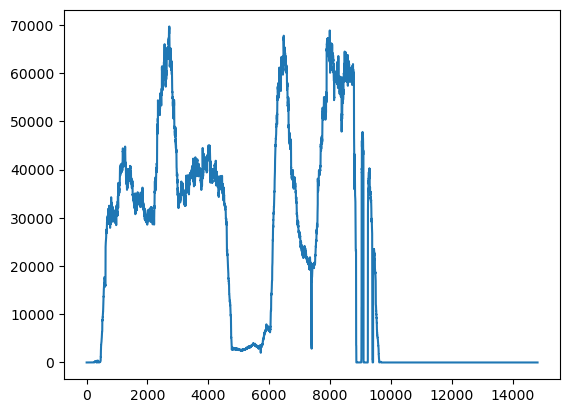

In [4]:
coverage = np.array(samfile.count_coverage('AF324493.2',start=1,end=10000))

coverage_full = np.sum(coverage,0)

plt.plot(coverage_full)

In [28]:
average = np.mean(coverage_full)

average_a = np.mean(coverage_full[450:2250])

average_b = np.mean(coverage_full[2250:4000])
average_c = np.mean(coverage_full[4000:5800])
average_d = np.mean(coverage_full[5800:7400])
average_e = np.mean(coverage_full[7400:9700])

cover_all = all([i>= 1000 for i in [average_a,average_b,average_c,average_d,average_e]])

print(average,average_a,average_b,average_c,average_d,average_e,cover_all)

20373.316041554237 31523.14888888889 45048.213142857145 15724.057222222222 33078.455625 37032.169130434784 True


In [25]:
a = 2
b = 3

all([i>2 for i in [a,b]])

False

In [9]:
mapped = samfile.mapped/float((samfile.mapped+samfile.unmapped))
mapping = mapped > 0.99

print(mapped, mapping)

0.9961154160652649 True


In [10]:
mapquality = 0

for read in samfile.fetch():
    mapquality += read.mapping_quality

mapquality = mapquality/float(samfile.mapped)
quality = mapquality > 55

print(mapquality, quality)

59.632949832738404 True


/tmp/ipykernel_2951762/3839906094.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(coverage_full, ))


Text(0.5, 1.0, '20373,0.996,59.63,True')

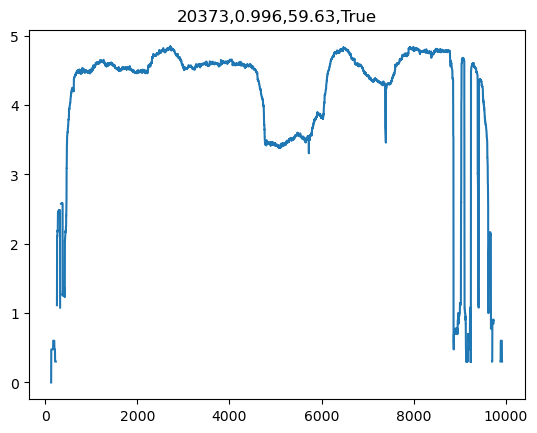

In [28]:
plt.plot(np.log10(coverage_full, ))
plt.title('{:.0f},{:.3f},{:.2f},{}'.format(average,mapped, mapquality, cover and mapping and quality))

In [26]:
print(type(coverage_full[500:600]))

<class 'numpy.ndarray'>
